In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv('../data/raw/xente_data.csv')

# View shape
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/xente_data.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv('../data/raw/xente data.csv')

# View shape
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset Shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
# Data overview
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
df.info()

Rows and Columns: (95662, 16)

Column Names:
['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']

Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null 

In [4]:
# Summary Statistics for Numerical Features
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [5]:
# Check for missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

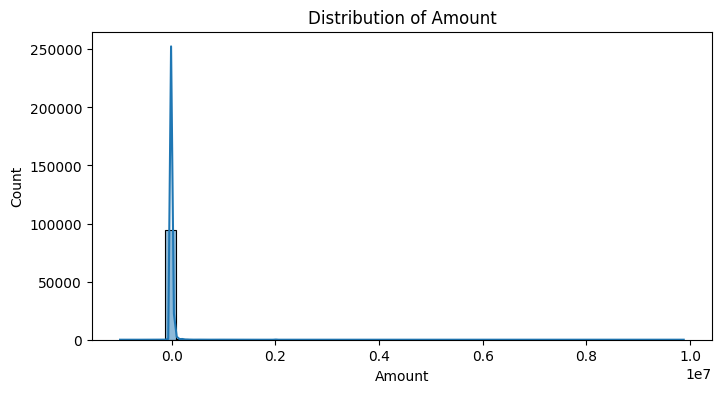

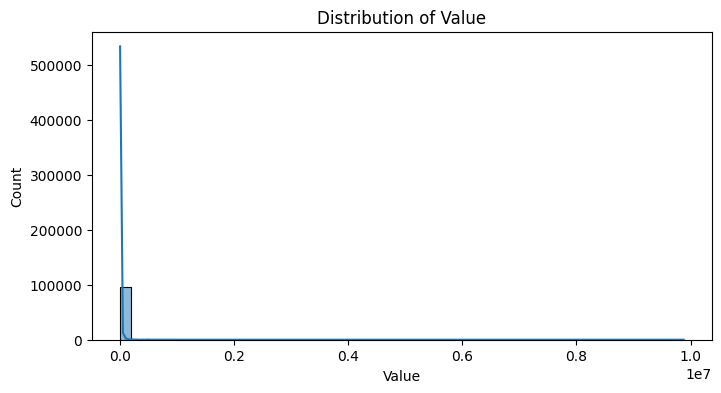

In [6]:
# Numerical Features Distribution

numerical_cols = ['Amount', 'Value']

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

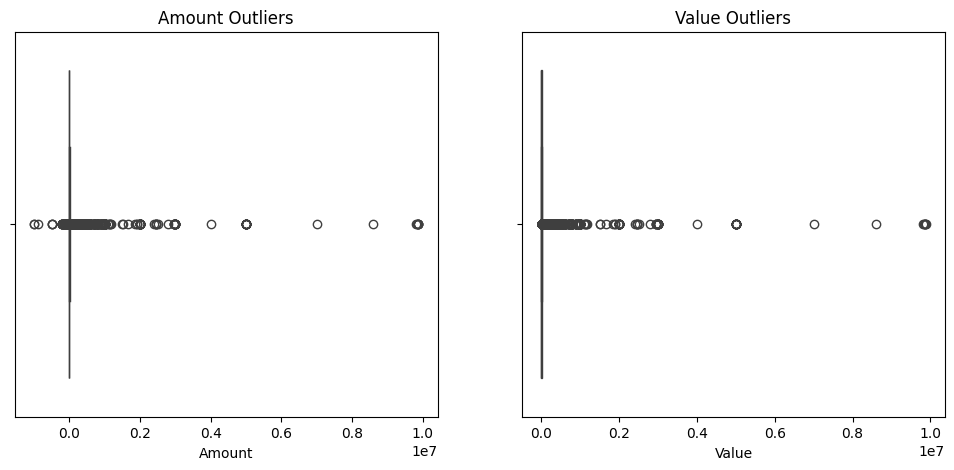

In [7]:
# Boxplots for Outlier Detection

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['Amount'])
plt.title('Amount Outliers')

plt.subplot(1,2,2)
sns.boxplot(x=df['Value'])
plt.title('Value Outliers')

plt.show()

In [8]:
# Categorical Features Overview

categorical_cols = [
    'CurrencyCode',
    'ProviderId',
    'ProductCategory',
    'ChannelId',
    'PricingStrategy'
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


CurrencyCode
CurrencyCode
UGX    95662
Name: count, dtype: int64

ProviderId
ProviderId
ProviderId_4    38189
ProviderId_6    34186
ProviderId_5    14542
ProviderId_1     5643
ProviderId_3     3084
ProviderId_2       18
Name: count, dtype: int64

ProductCategory
ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

ChannelId
ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

PricingStrategy
PricingStrategy
2    79848
4    13562
1     1867
0      385
Name: count, dtype: int64


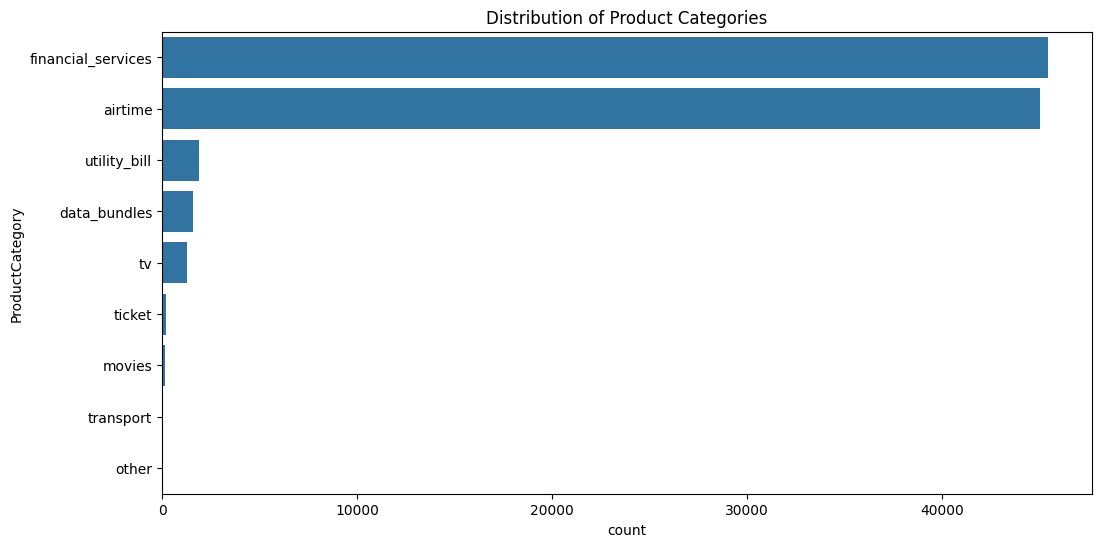

In [9]:
# Product Category Distribution

plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y='ProductCategory',
    order=df['ProductCategory'].value_counts().index
)
plt.title('Distribution of Product Categories')
plt.show()

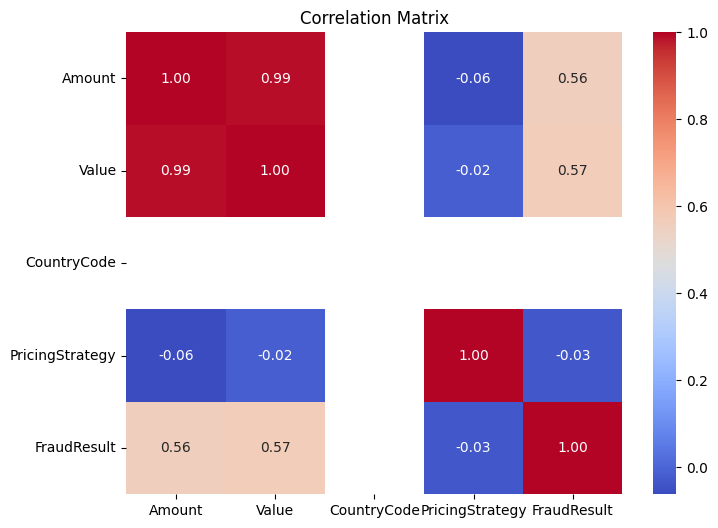

In [10]:
# Correlation Matrix

numerical_features = [
    'Amount',
    'Value',
    'CountryCode',
    'PricingStrategy',
    'FraudResult'
]

corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

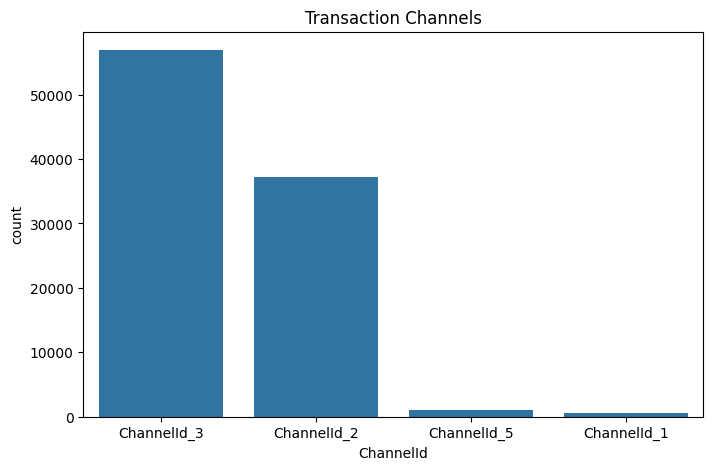

ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64


In [11]:
# Channel Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='ChannelId',
    order=df['ChannelId'].value_counts().index
)

plt.title('Transaction Channels')
plt.show()

print(df['ChannelId'].value_counts())

# Key Insights from Exploratory Data Analysis

## 1. High Data Quality
The dataset contains no missing values, indicating strong data completeness and reducing the need for extensive preprocessing during feature engineering.

## 2. Transaction Values are Highly Skewed
Both Amount and Value exhibit strong right-skewed distributions, with most transactions concentrated around lower values and a small number of extremely large transactions.

## 3. Significant Presence of Outliers
Boxplot analysis reveals numerous high-value outliers in both Amount and Value. These are likely genuine business transactions and should be carefully handled during modeling through scaling or transformation rather than removal.

## 4. Platform Activity is Concentrated in Few Categories
Financial Services and Airtime account for the overwhelming majority of transactions, suggesting that customer engagement is heavily focused on these service categories.

## 5. Transaction Channels are Unevenly Distributed
Most transactions occur through ChannelId_3 and ChannelId_2, indicating strong customer preference for specific transaction channels.

## 6. Strong Correlation Between Amount and Value
Amount and Value are almost perfectly correlated (0.99), suggesting redundancy between these features and the potential need for dimensionality reduction during feature engineering.

## 7. Fraud Shows Moderate Association with Transaction Size
FraudResult demonstrates moderate positive correlation with Amount and Value, indicating that transaction size may influence fraud detection outcomes.